# P9 - Analyses de Corrélation
## Guide pratique avec la fonction `correlation_bivariee()`

---

### 🎯 Principe

1. **Vous préparez vos données** (agrégation si nécessaire)
2. **Vous appelez la fonction** avec vos deux variables
3. **La fonction fait le reste** : détection du type, test approprié, visualisation

---

## 1. Configuration

In [2]:
import pandas as pd
import numpy as np
import sys

# Ajouter le dossier src au path
sys.path.append('../src')

# Importer notre fonction
from correlation_bivariee import correlation_bivariee #, generer_rapport

print("✅ Fonction chargée !")

✅ Fonction chargée !


In [13]:
# Charger les données préparées
DATA_PATH = "../data/processed/"

df = pd.read_csv(DATA_PATH + "transactions_enrichies.csv",
                 dtype={'id_prod': 'object', 'session_id': 'object', 'client_id': 'object',
                        'price': 'float64', 'categ': 'object', 'sex': 'object', 'birth': 'int64', 'segment_client': 'object', 'age_client': 'int64'})

df['date'] = pd.to_datetime(df['date'])

print(f"✅ {len(df):,} transactions chargées")
print(f"   Colonnes : {list(df.columns)}")

✅ 687,534 transactions chargées
   Colonnes : ['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex', 'birth', 'segment_client', 'age_client']


In [14]:
# Utiliser uniquement les clients B2C
df = df[df['segment_client'] == 'B2C']

---

## 2. Analyse Quali × Quali
### Genre ↔ Catégorie de produits

**Préparation ?** Aucune ! Chaque transaction a un genre et une catégorie.

📊 ANALYSE DE CORRÉLATION : sex ↔ categ
   Nombre d'observations : 640,734
   sex : object
   categ : object

   → Type : quali-quali
   → Test : Chi²
   → Graphique : heatmap

----------------------------------------------------------------------
📊 ANALYSE QUALI × QUALI
----------------------------------------------------------------------

🔹 Tableau de contingence :
categ       0       1      2
sex                         
f      200793  115721  16980
m      186488  104884  15868

🔹 Test du Chi² :
   χ² = 22.67
   ddl = 2
   p-value = 0.0000

🔹 V de Cramer = 0.006 → négligeable

🔹 Visualisation :


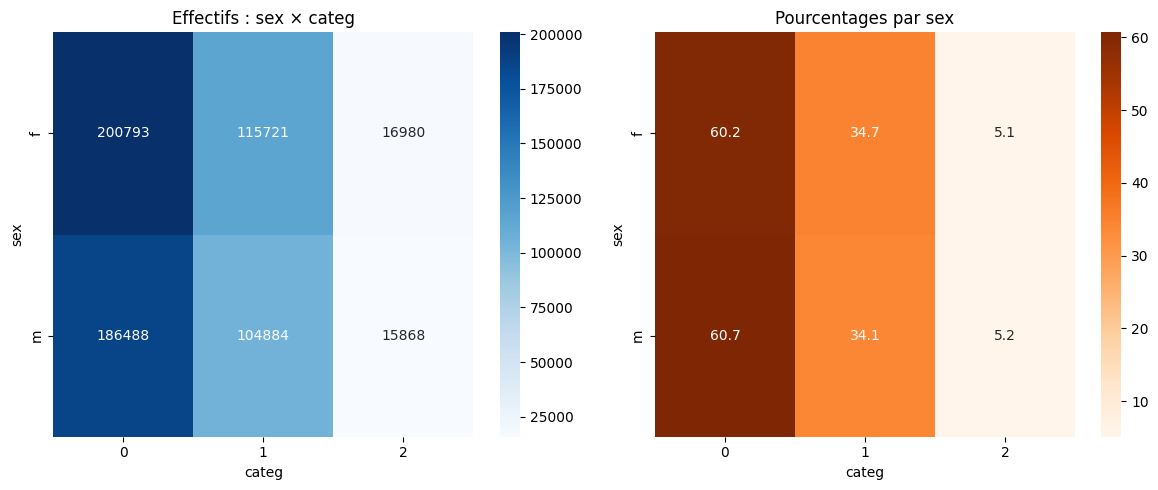


📋 CONCLUSION
   ✅ Relation SIGNIFICATIVE (p = 0.0000 < 0.05)
   → Force : négligeable


In [15]:
# Pas d'agrégation nécessaire → on utilise df directement
resultats_1 = correlation_bivariee(df, 'sex', 'categ')

---

## 3. Analyse Quanti × Quanti
### Âge ↔ Montant total des achats

**⚠️ Préparation nécessaire !**

On veut savoir si les clients âgés dépensent plus **au total**.  
→ Il faut agréger par client : un client = un âge, un montant total.

In [17]:
# ÉTAPE 1 : Agréger par client
df_clients = df.groupby('client_id').agg({
    'age_client': 'first',      # L'âge est le même pour toutes les transactions d'un client
    'price': 'sum'       # Somme des achats = montant total
}).reset_index()

# Renommer pour plus de clarté
df_clients.columns = ['client_id', 'age', 'montant_total']

print(f"✅ {len(df_clients):,} clients (au lieu de {len(df):,} transactions)")
display(df_clients.head())

✅ 8,596 clients (au lieu de 640,734 transactions)


,client_id,age,montant_total
0,c_1,71,629.02
1,c_10,70,1353.60
2,c_100,34,254.85
3,c_1000,60,2291.88
4,c_1001,44,1823.85


📊 ANALYSE DE CORRÉLATION : age ↔ montant_total
   Nombre d'observations : 8,596
   age : int64
   montant_total : float64

   → Type : quanti-quanti
   → Test : Pearson ou Spearman
   → Graphique : scatterplot

----------------------------------------------------------------------
📊 ANALYSE QUANTI × QUANTI
----------------------------------------------------------------------

🔹 Tests de normalité (Shapiro-Wilk) :
   age : p = 0.0000 → ❌ Non normale
   montant_total : p = 0.0000 → ❌ Non normale

   → Test choisi : Spearman

🔹 Test de Spearman :
   ρ = -0.1845
   p-value = 0.0000

🔹 Corrélation négative, force faible

🔹 Visualisation :


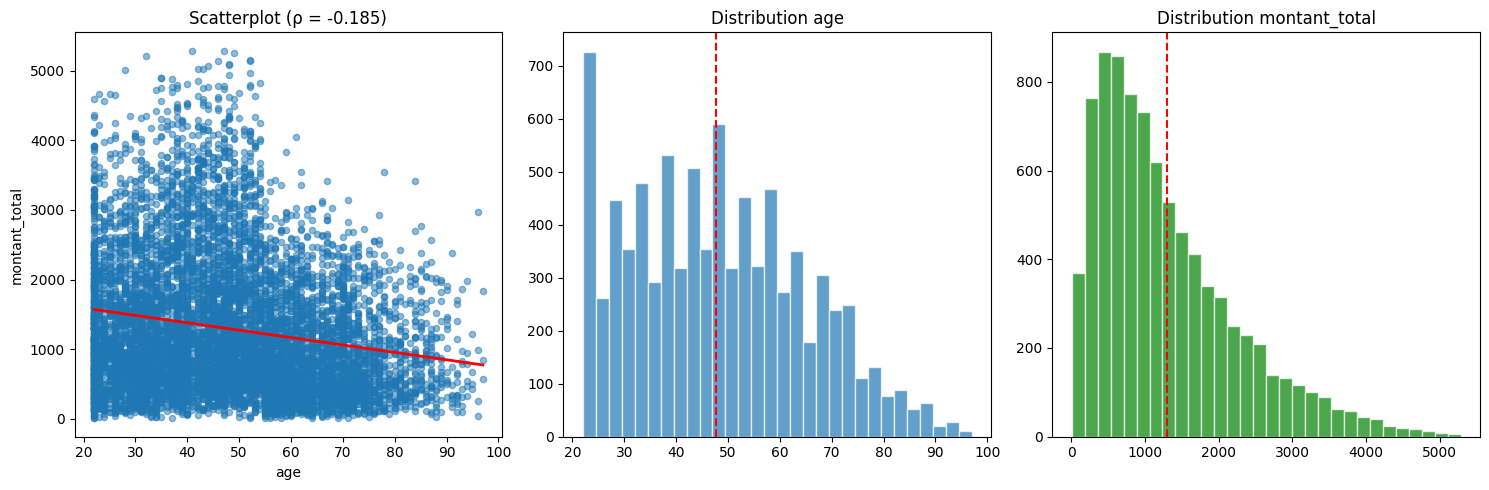


📋 CONCLUSION
   ✅ Relation SIGNIFICATIVE (p = 0.0000 < 0.05)
   → Force : faible


In [18]:
# ÉTAPE 2 : Appeler la fonction sur les données agrégées
resultats_2 = correlation_bivariee(df_clients, 'age', 'montant_total')

---

## 4. Analyse Quali × Quanti
### Catégorie ↔ Prix unitaire

**Préparation ?** Aucune ! Chaque transaction a une catégorie et un prix.

📊 ANALYSE DE CORRÉLATION : categ ↔ price
   Nombre d'observations : 640,734
   categ : object
   price : float64

   → Type : quali-quanti
   → Test : ANOVA ou Kruskal-Wallis
   → Graphique : boxplot

----------------------------------------------------------------------
📊 ANALYSE QUALI × QUANTI
----------------------------------------------------------------------

🔹 Statistiques par groupe :
        count   mean    std  median
categ                              
0      387281  10.64   4.93    9.99
1      220605  20.49   7.58   19.08
2       32848  76.23  39.81   62.83

🔹 Tests de normalité (Shapiro-Wilk) par groupe :
   categ=0 : p = 0.0000 → ❌
   categ=1 : p = 0.0000 → ❌
   categ=2 : p = 0.0000 → ❌

   → Test choisi : Kruskal-Wallis

🔹 Test Kruskal-Wallis :
   Statistique = 306629.18
   p-value = 0.0000
   ε² = 0.4786 → Effet fort

🔹 Visualisation :


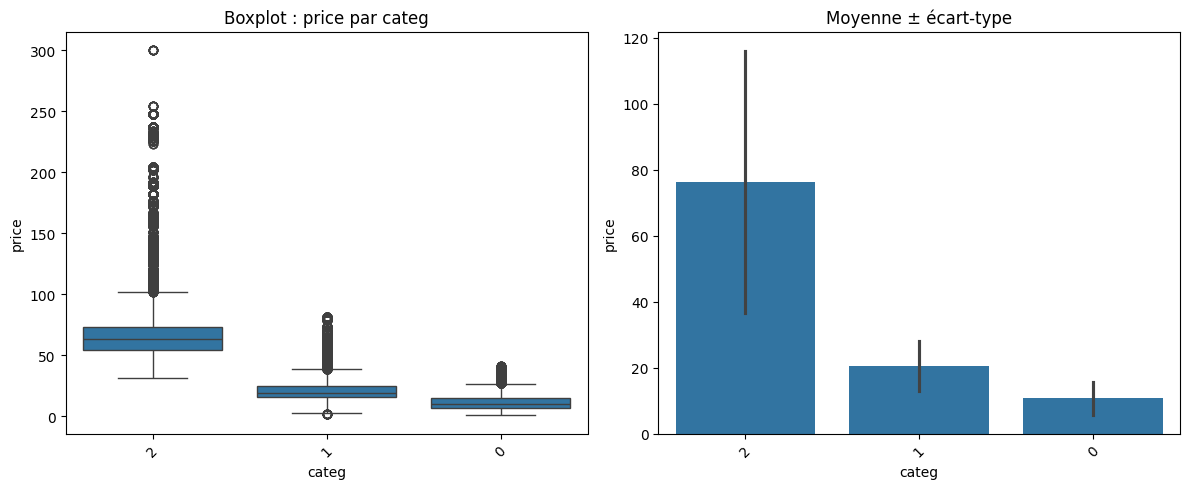


📋 CONCLUSION
   ✅ Relation SIGNIFICATIVE (p = 0.0000 < 0.05)
   → Force : fort


In [19]:
# Pas d'agrégation nécessaire
resultats_3 = correlation_bivariee(df, 'categ', 'price')

---

## 5. Récapitulatif

In [22]:
# Tableau récapitulatif
tous_resultats = [
    ('Genre × Catégorie', resultats_1),
    ('Âge × Montant total', resultats_2),
    ('Catégorie × Prix', resultats_3)
]

recap = []
for nom, res in tous_resultats:
    recap.append({
        'Analyse': nom,
        'Type': res['type'],
        'Test': res['test'],
        'p-value': f"{res['p_value']:.4f}",
        'Significatif': '✅' if res['significatif'] else '❌',
        'Force': res['force']
    })

print("\n📋 RÉCAPITULATIF")
display(pd.DataFrame(recap))


📋 RÉCAPITULATIF


,Analyse,Type,Test,p-value,Significatif,Force
0,Genre × Catégorie,quali-quali,Chi²,0.0000,✅,négligeable
1,Âge × Montant total,quanti-quanti,Spearman,0.0000,✅,faible
2,Catégorie × Prix,quali-quanti,Kruskal-Wallis,0.0000,✅,fort


---

## 6. Guide : Quand agréger ?

| Question métier | Agrégation |
|-----------------|------------|
| Les hommes achètent-ils les mêmes catégories ? | ❌ Non (niveau transaction) |
| Les clients âgés dépensent-ils plus **au total** ? | ✅ Oui par client (`sum`) |
| Les clients âgés achètent-ils des produits **plus chers** ? | ✅ Oui par client (`mean`) |
| Quelle catégorie a les produits les plus chers ? | ❌ Non (niveau transaction) |

### Modèle d'agrégation

```python
df_agrege = df.groupby('client_id').agg({
    'age': 'first',       # Variable quali ou fixe par client
    'price': 'sum'        # Variable quanti à agréger
}).reset_index()
```